In [1]:
import datetime
from dataclasses import dataclass
from datetime import timedelta
import pathlib
import joblib
import pandera.polars as pa
import pandera.typing.polars
from pandera.typing.polars import DataFrame
from pandera.typing.polars import Series
import polars as pl
from typing import Annotated
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
#from notebooks.overnight_range_breakout_model import test_start
from typing import Generator

In [2]:
##INPUTS

MODEL_LOOKBACKS = [1,7,14,21,28,35,42,49,98,147,196]
remove_sundays=False
remove_saturday=False

include_minors=False
dukas_data=False
STANDARD_DUKAS = "multi_asset_weights_non_majors_dukas_2016_jan_fourth"
model_name = STANDARD_DUKAS
if remove_saturday:
    model_name = model_name + "_no_saturday"
if remove_sundays:
    model_name = model_name + "_no_sunday"

if not dukas_data:
    model_name=model_name.replace("dukas", "oanda")

# Run this notebook from the project root so artifacts are saved beside it.
ARTIFACT_DIRECTORY = pathlib.Path("C:/Code/Trading/2026/ml/src/notebooks/src/notebooks")
WEIGHTS_ARTIFACT_PATH = ARTIFACT_DIRECTORY / f"{model_name}.parquet"
MODEL_ARTIFACT_PATH = ARTIFACT_DIRECTORY / f"{model_name}.joblib"





In [3]:
model_name

'multi_asset_weights_non_majors_oanda_2016_jan_fourth'

In [4]:
## CONSTANTS
CCYS = ['jpy','chf','cad','aud','nzd','eur','gbp']
INVERSE_CCYS = ['chf','jpy','cad']
#NON_MAJORS = ['hkd','mxn','nok','sgd','sek','try','zar']
NON_MAJORS = ['nok','sek','mxn']
INITIAL_CUT = datetime.datetime(2016, 1, 4, tzinfo=datetime.timezone.utc)

TRAIN_DAYS=30*12*5
TEST_DAYS=30

if include_minors:
    INVERSE_CCYS.extend(NON_MAJORS)
    CCYS.extend(NON_MAJORS)
    # INITIAL_CUT = datetime.datetime(2020, 1, 1, tzinfo=datetime.timezone.utc)
    TRAIN_DAYS=30*12*5



# training_start = datetime.datetime(2004,1,1,tzinfo=datetime.timezone.utc)
# training_end = datetime.datetime(2014,1,1,tzinfo=datetime.timezone.utc)
# test_start = datetime.datetime(2014,1,1,tzinfo=datetime.timezone.utc)
# test_end = datetime.datetime(2024,2,1,tzinfo=datetime.timezone.utc)



In [5]:
RAW_OHLC_COLUMNS = [
    f"{ccy}_{field}"
    for ccy in CCYS
    for field in ("open", "high", "low", "close")
]
class DayBar(pa.DataFrameModel):
    timestamp: pandera.typing.polars.Series[pl.Datetime("ns", "UTC")]
    open: pandera.typing.polars.Series[float]
    high: pandera.typing.polars.Series[float]
    low: pandera.typing.polars.Series[float]
    close: pandera.typing.polars.Series[float]

#OANDA
def get_oanda_hourly_file_path(ccy: str):
    if ccy in INVERSE_CCYS:
        pair = f'usd{ccy}'
    else:
        pair = f'{ccy}usd'
    return pathlib.Path(r'D:\Trading\2026\Data\Oanda\\',f"oanda_{pair}_hourly.parquet")


def read_oanda_hourly_data(ccy: str) -> DataFrame[DayBar]:
    df = pl.read_parquet(get_oanda_hourly_file_path(ccy))
    #
    df = df.with_columns(
        pl.col("timestamp")
          .dt.cast_time_unit("ns")
          .dt.replace_time_zone("UTC")
    )

    if ccy in INVERSE_CCYS:
        df = df.with_columns(
            (1 / pl.col("open")).alias(f"open"),
            (1 / pl.col("low")).alias("high"),
            (1 / pl.col("high")).alias("low"),
            (1 / pl.col("close")).alias("close"),
        )
    return DayBar.validate(df)

def hourly_to_daily(df: DataFrame[DayBar]) -> DataFrame[DayBar]:
    daily = (
        df.sort("timestamp")  # group_by_dynamic requires sorted input
        .group_by_dynamic("timestamp", every="1d", closed="left", label="left")
        .agg(
            pl.col("open").first(),
            pl.col("high").max(),
            pl.col("low").min(),
            pl.col("close").last(),
        )
    )

    saturdays = (
        daily.filter(pl.col("timestamp").dt.weekday() == 5)  # Monday=1 ... Friday=5
        .select(
            pl.col("timestamp").dt.offset_by("1d"),
            pl.col("close").alias("open"),
            pl.col("close").alias("high"),
            pl.col("close").alias("low"),
            pl.col("close"),
        )
        .join(daily.select("timestamp"), on="timestamp", how="anti")  # don't duplicate real Saturday bars
    )

    combined = pl.concat([daily, saturdays]).sort("timestamp")
    return DayBar.validate(combined)

def read_oanda_data(ccy: str) -> DataFrame[DayBar]:
    df = hourly_to_daily(read_oanda_hourly_data(ccy))

    return DayBar.validate(df)

def get_dukas_file_path(ccy: str):
    if ccy in INVERSE_CCYS:
        pair = f'usd{ccy}'
    else:
        pair = f'{ccy}usd'
    return pathlib.Path(r'D:\Trading\2026\\',f"{pair}_d1_sep_2026.csv")



def read_dukas_data(ccy: str) -> DataFrame[DayBar]:
    df = pl.read_csv(get_dukas_file_path(ccy))

    df = df.with_columns(
        pl.from_epoch("timestamp", time_unit="ms")
          .dt.cast_time_unit("ns")
          .dt.replace_time_zone("UTC")
    )

    if ccy in INVERSE_CCYS:
        df = df.with_columns(
            (1 / pl.col("open")).alias(f"open"),
            (1 / pl.col("low")).alias("high"),
            (1 / pl.col("high")).alias("low"),
            (1 / pl.col("close")).alias("close"),
        )
    return DayBar.validate(df)


if dukas_data:
    read_data=read_dukas_data
else:
    read_data = read_oanda_data

In [7]:



@dataclass(frozen=True)
class TrainTestRange(object):
    train_start: datetime
    train_end: datetime
    test_start: datetime
    test_end: datetime

def split_day_periods(
    start_date: datetime.datetime, end_date: datetime.datetime, train_days: int, test_days: int
) -> Generator[TrainTestRange, None, None]:

    train_start = start_date
    train_end = train_start + timedelta(days=train_days)
    test_start = train_end + timedelta(days=1)
    test_end = test_start + timedelta(days=test_days)
    while test_end < end_date:
        yield TrainTestRange(
            train_start=train_start,
            train_end=train_end,
            test_start=test_start,
            test_end=test_end)
        train_start += timedelta(days=test_days+1)
        train_end +=  timedelta(days=test_days+1)
        test_start += timedelta(days=test_days+1)
        test_end +=  timedelta(days=test_days+1)
    # potentially want to yield the last train/test range


In [8]:


def get_model_feature_columns(df: pl.DataFrame) -> list[str]:
    """Return numeric model features, excluding raw prices and all targets."""
    excluded = {"timestamp", *RAW_OHLC_COLUMNS}
    excluded.update(column for column in df.columns if column.endswith("_target"))
    return [
        column
        for column, dtype in df.schema.items()
        if column not in excluded and (dtype.is_numeric() or dtype == pl.Boolean)
    ]


def _model_feature_frame(df: pl.DataFrame, feature_columns: list[str]) -> pl.DataFrame:
    """Cast features to floats and replace NaN/infinite values with null."""
    expressions = []
    for column in feature_columns:
        feature = pl.col(column).cast(pl.Float64)
        expressions.append(
            pl.when(feature.is_nan() | feature.is_infinite())
            .then(None)
            .otherwise(feature)
            .alias(column)
        )
    return df.select(expressions)


def train_xgboost_models(
    df: pl.DataFrame,
    validation_fraction: float = 0.20,
    model_params: dict | None = None,
) -> tuple[dict[str, XGBRegressor], pl.DataFrame, list[str]]:
    """Train one time-ordered XGBoost model per currency.

    Raw OHLC levels and every target column are excluded. One row is purged
    between train and validation because each target uses the next day's close.
    """
    if not 0 < validation_fraction < 1:
        raise ValueError("validation_fraction must be between 0 and 1")

    feature_columns = get_model_feature_columns(df)
    if not feature_columns:
        raise ValueError("No numeric feature columns remain after exclusions")

    parameters = {
        "objective": "reg:squarederror",
        "n_estimators": 350,
        "learning_rate": 0.03,
        "max_depth": 4,
        "min_child_weight": 10,
        "subsample": 0.8,
        "colsample_bytree": 0.7,
        "reg_alpha": 0.1,
        "reg_lambda": 1.0,
        "early_stopping_rounds": 30,
        "eval_metric": "rmse",
        "tree_method": "hist",
        "random_state": 15684,
        "n_jobs": -1,
    }
    if model_params:
        parameters.update(model_params)

    models: dict[str, XGBRegressor] = {}
    metrics = []
    for ccy in CCYS:
        target_column = f"{ccy}_target"
        model_df = calculate_target(df, ccy) if target_column not in df.columns else df
        model_df = model_df.filter(pl.col(target_column).is_not_null())
        split_index = int(model_df.height * (1 - validation_fraction))
        train_end = split_index - 1  # Purge the target that ends in validation.
        if train_end < 30 or model_df.height - split_index < 10:
            raise ValueError("Insufficient rows for the requested train/validation split")

        feature_frame = _model_feature_frame(model_df, feature_columns)
        x_train = feature_frame.slice(0, train_end).to_numpy()
        y_train = model_df[:train_end].get_column(target_column).to_numpy().reshape(-1)
        x_validation = feature_frame.slice(split_index).to_numpy()
        y_validation = model_df[split_index:].get_column(target_column).to_numpy().reshape(-1)

        model = XGBRegressor(**parameters)
        model.fit(x_train, y_train, eval_set=[(x_validation, y_validation)], verbose=False)
        prediction = model.predict(x_validation)
        correlation = (
            None
            if np.std(y_validation) == 0 or np.std(prediction) == 0
            else float(np.corrcoef(y_validation, prediction)[0, 1])
        )
        models[ccy] = model
        metrics.append({
            "ccy": ccy,
            "train_rows": train_end,
            "validation_rows": len(y_validation),
            "rmse": float(mean_squared_error(y_validation, prediction) ** 0.5),
            "correlation": correlation,
            "directional_accuracy": float(np.mean(np.sign(y_validation) == np.sign(prediction))),
            "best_iteration": getattr(model, "best_iteration", parameters["n_estimators"] - 1),
        })

    return models, pl.DataFrame(metrics), feature_columns


# Example after building features:
# models, model_metrics, model_features = train_xgboost_models(all)
# model_metrics


def add_model_features(df: pl.DataFrame, lookbacks: list[int]) -> pl.DataFrame:
    """Build the curated, normalised feature set used by the models."""
    result = add_candle_features(df)
    result = add_calendar_features(result)
    for lookback in lookbacks:
        result = add_return(result, lookback)
        result = add_velocity(result, lookback)
        result = add_cross_sectional_features(result, lookback)
        result = add_volatility_features(result, lookback)
        result = add_range_features(result, lookback)
        result = add_trend_features(result, lookback)
        result = add_cross_asset_features(result, lookback)
    return result


def train_and_evaluate_xgboost_strategy(
    df: pl.DataFrame,
    test_fraction: float = 0.20,
    validation_fraction: float = 0.20,
    periods_per_year: int = 252,
    model_params: dict | None = None,
) -> tuple[dict[str, XGBRegressor], pl.DataFrame, pl.DataFrame, list[str]]:
    """Fit models, convert test predictions to neutral weights, and evaluate.

    The final test block is never used for fitting or early stopping. A row is
    purged at each split because a target at time t uses the close at t + 1.
    """
    if not 0 < test_fraction < 1 or not 0 < validation_fraction < 1:
        raise ValueError("test_fraction and validation_fraction must be between 0 and 1")

    labelled = df
    for ccy in CCYS:
        labelled = calculate_target(labelled, ccy)
    target_columns = [f"{ccy}_target" for ccy in CCYS]
    labelled = labelled.drop_nulls(target_columns)
    feature_columns = get_model_feature_columns(labelled)

    test_start = int(labelled.height * (1 - test_fraction))
    validation_start = int(test_start * (1 - validation_fraction))
    fit_rows = validation_start - 1
    validation_rows = test_start - validation_start - 1
    test_rows = labelled.height - test_start
    if fit_rows < 30 or validation_rows < 10 or test_rows < 10:
        raise ValueError("Insufficient rows for purged train/validation/test splits")

    feature_frame = _model_feature_frame(labelled, feature_columns)
    x_fit = feature_frame.slice(0, fit_rows).to_numpy()
    x_validation = feature_frame.slice(validation_start, validation_rows).to_numpy()
    x_test = feature_frame.slice(test_start).to_numpy()
    parameters = {
        "objective": "reg:squarederror", "n_estimators": 300, "learning_rate": 0.03,
        "max_depth": 3, "min_child_weight": 10, "subsample": 0.8,
        "colsample_bytree": 0.7, "reg_alpha": 0.1, "reg_lambda": 1.0,
        "early_stopping_rounds": 30, "eval_metric": "rmse",
        "tree_method": "hist", "random_state": 42, "n_jobs": -1,
    }
    if model_params:
        parameters.update(model_params)

    models = {}
    test_results = labelled.slice(test_start).select(["timestamp", *target_columns])
    for ccy in CCYS:
        target = labelled.get_column(f"{ccy}_target").to_numpy().reshape(-1)
        model = XGBRegressor(**parameters)
        model.fit(
            x_fit, target[:fit_rows],
            eval_set=[(x_validation, target[validation_start:validation_start + validation_rows])],
            verbose=False,
        )
        models[ccy] = model
        test_results = test_results.with_columns(
            pl.Series(f"{ccy}_prediction", np.asarray(model.predict(x_test)).reshape(-1))
        )

    prediction_columns = [f"{ccy}_prediction" for ccy in CCYS]
    mean_prediction = pl.mean_horizontal(prediction_columns)
    gross_signal = pl.sum_horizontal([(pl.col(column) - mean_prediction).abs() for column in prediction_columns])
    weight_expressions = [
        pl.when(gross_signal > 0)
        .then((pl.col(f"{ccy}_prediction") - mean_prediction) / gross_signal)
        .otherwise(0.0)
        .alias(f"{ccy}_weight")
        for ccy in CCYS
    ]
    test_results = test_results.with_columns(weight_expressions)
    portfolio_return = pl.sum_horizontal([
        pl.col(f"{ccy}_weight") * pl.col(f"{ccy}_target") for ccy in CCYS
    ])
    test_results = test_results.with_columns(portfolio_return.alias("portfolio_return"))

    returns = test_results.get_column("portfolio_return").to_numpy()
    equity = np.cumprod(1 + returns)
    drawdown = equity / np.maximum.accumulate(equity) - 1
    volatility = np.std(returns, ddof=1)
    annualised_return = equity[-1] ** (periods_per_year / len(returns)) - 1
    annualised_volatility = volatility * periods_per_year ** 0.5
    metrics = pl.DataFrame({
        "test_rows": [len(returns)],
        "total_return": [float(equity[-1] - 1)],
        "annualised_return": [float(annualised_return)],
        "annualised_volatility": [float(annualised_volatility)],
        "sharpe": [None if volatility == 0 else float(np.mean(returns) / volatility * periods_per_year ** 0.5)],
        "max_drawdown": [float(drawdown.min())],
    })
    test_results = test_results.with_columns([
        pl.Series("portfolio_equity", equity),
        pl.Series("portfolio_drawdown", drawdown),
    ])
    return models, test_results, metrics, feature_columns


def generate_weights(
    models: dict[str, XGBRegressor],
    features: pl.DataFrame,
    feature_columns: list[str],
) -> pl.DataFrame:
    """Generate dollar-neutral weights for one or more unseen feature rows.

    ``features`` must have been created with the same feature pipeline and
    contain every column in ``feature_columns``. It may include timestamp and
    raw OHLC columns; neither is supplied to the models.
    """
    missing_features = set(feature_columns) - set(features.columns)
    if missing_features:
        raise ValueError(f"Missing model features: {sorted(missing_features)}")
    missing_models = set(CCYS) - set(models)
    if missing_models:
        raise ValueError(f"Missing currency models: {sorted(missing_models)}")

    model_input = _model_feature_frame(features, feature_columns).to_numpy()
    output = features.select("timestamp") if "timestamp" in features.columns else pl.DataFrame()
    for ccy in CCYS:
        output = output.with_columns(
            pl.Series(
                f"{ccy}_prediction",
                np.asarray(models[ccy].predict(model_input)).reshape(-1),
            )
        )

    prediction_columns = [f"{ccy}_prediction" for ccy in CCYS]
    mean_prediction = pl.mean_horizontal(prediction_columns)
    gross_signal = pl.sum_horizontal([
        (pl.col(column) - mean_prediction).abs() for column in prediction_columns
    ])
    return output.with_columns([
        pl.when(gross_signal > 0)
        .then((pl.col(f"{ccy}_prediction") - mean_prediction) / gross_signal)
        .otherwise(0.0)
        .alias(f"{ccy}_weight")
        for ccy in CCYS
    ])


def calculate_strategy_returns(
    weights: pl.DataFrame,
    data: pl.DataFrame,
    periods_per_year: int = 252,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Join weights to realised targets and calculate out-of-sample returns.

    Pass the full feature frame as ``data``. The weights' timestamps select
    the evaluation window, while the following row in the full frame supplies
    each date's next-day target return.
    """
    if "timestamp" not in weights.columns or "timestamp" not in data.columns:
        raise ValueError("weights and data must both contain timestamp")
    weight_columns = [f"{ccy}_weight" for ccy in CCYS]
    missing_weights = set(weight_columns) - set(weights.columns)
    if missing_weights:
        raise ValueError(f"Missing weight columns: {sorted(missing_weights)}")

    target_columns = [f"{ccy}_target" for ccy in CCYS]
    labelled = data
    if not set(target_columns).issubset(data.columns):
        for ccy in CCYS:
            labelled = calculate_target(labelled, ccy)

    returns = (
        weights.join(labelled.select(["timestamp", *target_columns]), on="timestamp", how="inner")
        .drop_nulls(target_columns)
        .with_columns(
            pl.sum_horizontal([
                pl.col(f"{ccy}_weight") * pl.col(f"{ccy}_target")
                for ccy in CCYS
            ]).alias("portfolio_return")
        )
        .sort("timestamp")
    )
    if returns.is_empty():
        raise ValueError("No weight rows have realised target returns")

    daily_returns = returns.get_column("portfolio_return").to_numpy()
    equity = np.cumprod(1 + daily_returns)
    drawdown = equity / np.maximum.accumulate(equity) - 1
    volatility = np.std(daily_returns, ddof=1) if len(daily_returns) > 1 else 0.0
    metrics = pl.DataFrame({
        "rows": [len(daily_returns)],
        "total_return": [float(equity[-1] - 1)],
        "annualised_return": [float(equity[-1] ** (periods_per_year / len(daily_returns)) - 1)],
        "annualised_volatility": [float(volatility * periods_per_year ** 0.5)],
        "sharpe": [None if volatility == 0 else float(np.mean(daily_returns) / volatility * periods_per_year ** 0.5)],
        "max_drawdown": [float(drawdown.min())],
    })
    returns = returns.with_columns([
        pl.Series("portfolio_equity", equity),
        pl.Series("portfolio_drawdown", drawdown),
    ])
    return returns, metrics


def calculate_strategy_returns_single_asset(
    weights: pl.DataFrame,
    data: pl.DataFrame,
    periods_per_year: int = 252,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Evaluate a strategy that trades only the strongest daily signal.

    The largest absolute input weight determines the selected currency. Its
    sign becomes a unit long or short position; every other currency has a
    zero position. Ties are resolved by the order of ``CCYS``.
    """
    if "timestamp" not in weights.columns or "timestamp" not in data.columns:
        raise ValueError("weights and data must both contain timestamp")
    weight_columns = [f"{ccy}_weight" for ccy in CCYS]
    missing_weights = set(weight_columns) - set(weights.columns)
    if missing_weights:
        raise ValueError(f"Missing weight columns: {sorted(missing_weights)}")

    target_columns = [f"{ccy}_target" for ccy in CCYS]
    labelled = data
    if not set(target_columns).issubset(data.columns):
        for ccy in CCYS:
            labelled = calculate_target(labelled, ccy)

    absolute_weights = [pl.col(column).abs() for column in weight_columns]
    selected_weights = [pl.col("timestamp")]
    prior_is_larger = []
    for ccy, column, absolute_weight in zip(CCYS, weight_columns, absolute_weights):
        is_selected = pl.all_horizontal([absolute_weight >= other for other in absolute_weights])
        if prior_is_larger:
            is_selected = is_selected & ~pl.any_horizontal(prior_is_larger)
        selected_weights.append(
            pl.when(is_selected).then(pl.col(column).sign()).otherwise(0.0).alias(column)
        )
        prior_is_larger.append(absolute_weight >= pl.max_horizontal(absolute_weights))
    single_asset_weights = weights.select(selected_weights)

    returns = (
        single_asset_weights.join(labelled.select(["timestamp", *target_columns]), on="timestamp", how="inner")
        .drop_nulls(target_columns)
        .with_columns(
            pl.sum_horizontal([
                pl.col(f"{ccy}_weight") * pl.col(f"{ccy}_target")
                for ccy in CCYS
            ]).alias("portfolio_return")
        )
        .sort("timestamp")
    )
    if returns.is_empty():
        raise ValueError("No weight rows have realised target returns")

    daily_returns = returns.get_column("portfolio_return").to_numpy()
    equity = np.cumprod(1 + daily_returns)
    drawdown = equity / np.maximum.accumulate(equity) - 1
    volatility = np.std(daily_returns, ddof=1) if len(daily_returns) > 1 else 0.0
    metrics = pl.DataFrame({
        "rows": [len(daily_returns)],
        "total_return": [float(equity[-1] - 1)],
        "annualised_return": [float(equity[-1] ** (periods_per_year / len(daily_returns)) - 1)],
        "annualised_volatility": [float(volatility * periods_per_year ** 0.5)],
        "sharpe": [None if volatility == 0 else float(np.mean(daily_returns) / volatility * periods_per_year ** 0.5)],
        "max_drawdown": [float(drawdown.min())],
    })
    returns = returns.with_columns([
        pl.Series("portfolio_equity", equity),
        pl.Series("portfolio_drawdown", drawdown),
    ])
    return returns, metrics

def calculate_strategy_returns_vol_targetting(
    weights: pl.DataFrame,
    data: pl.DataFrame,
    periods_per_year: int = 252,
    target_volatility: float = 0.20,
    volatility_window: int = 20,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Calculate strategy returns scaled to an annualised volatility target.

    Scaling uses the preceding ``volatility_window`` unscaled returns, avoiding
    look-ahead bias. Returns are zero until a valid full-window estimate exists.
    """
    if (
        isinstance(periods_per_year, bool)
        or not isinstance(periods_per_year, (int, np.integer))
        or periods_per_year <= 0
    ):
        raise ValueError("periods_per_year must be a positive integer")
    if (
        isinstance(volatility_window, bool)
        or not isinstance(volatility_window, (int, np.integer))
        or volatility_window < 2
    ):
        raise ValueError("volatility_window must be an integer of at least 2")
    if not np.isfinite(target_volatility) or target_volatility <= 0:
        raise ValueError("target_volatility must be positive and finite")
    if "timestamp" not in weights.columns or "timestamp" not in data.columns:
        raise ValueError("weights and data must both contain timestamp")

    weight_columns = [f"{ccy}_weight" for ccy in CCYS]
    missing_weights = set(weight_columns) - set(weights.columns)
    if missing_weights:
        raise ValueError(f"Missing weight columns: {sorted(missing_weights)}")

    target_columns = [f"{ccy}_target" for ccy in CCYS]
    labelled = data
    if not set(target_columns).issubset(data.columns):
        for ccy in CCYS:
            labelled = calculate_target(labelled, ccy)

    returns = (
        weights.join(
            labelled.select(["timestamp", *target_columns]),
            on="timestamp",
            how="inner",
        )
        .drop_nulls(target_columns)
        .with_columns(
            pl.sum_horizontal([
                pl.col(f"{ccy}_weight") * pl.col(f"{ccy}_target")
                for ccy in CCYS
            ]).alias("unscaled_portfolio_return")
        )
        .sort("timestamp")
    )
    if returns.is_empty():
        raise ValueError("No weight rows have realised target returns")

    unscaled_returns = (
        returns.get_column("unscaled_portfolio_return").to_numpy().astype(float)
    )
    if not np.isfinite(unscaled_returns).all():
        raise ValueError("Portfolio returns must be finite")

    realised_annualised_volatility = np.full(len(unscaled_returns), np.nan)
    volatility_scaler = np.zeros(len(unscaled_returns))

    for index in range(volatility_window, len(unscaled_returns)):
        trailing_returns = unscaled_returns[index - volatility_window:index]
        realised_volatility = (
            np.std(trailing_returns, ddof=1) * periods_per_year ** 0.5
        )
        realised_annualised_volatility[index] = realised_volatility

        if np.isfinite(realised_volatility) and realised_volatility > 0:
            volatility_scaler[index] = target_volatility / realised_volatility

    daily_returns = unscaled_returns * volatility_scaler
    equity = np.cumprod(1 + daily_returns)
    drawdown = equity / np.maximum.accumulate(equity) - 1
    volatility = np.std(daily_returns, ddof=1) if len(daily_returns) > 1 else 0.0

    metrics = pl.DataFrame({
        "rows": [len(daily_returns)],
        "target_volatility": [float(target_volatility)],
        "volatility_window": [int(volatility_window)],
        "total_return": [float(equity[-1] - 1)],
        "annualised_return": [
            float(equity[-1] ** (periods_per_year / len(daily_returns)) - 1)
        ],
        "annualised_volatility": [
            float(volatility * periods_per_year ** 0.5)
        ],
        "sharpe": [
            None if volatility == 0
            else float(
                np.mean(daily_returns) / volatility * periods_per_year ** 0.5
            )
        ],
        "max_drawdown": [float(drawdown.min())],
    })

    returns = returns.with_columns([
        pl.Series(
            "realised_annualised_volatility",
            realised_annualised_volatility,
        ),
        pl.Series("volatility_scaler", volatility_scaler),
        pl.Series("portfolio_return", daily_returns),
        pl.Series("portfolio_equity", equity),
        pl.Series("portfolio_drawdown", drawdown),
    ])
    return returns, metrics

@dataclass(frozen=True)
class TradingSimulationConfig:
    """Configuration for close-to-next-close USD trading simulation."""

    starting_balance: float
    minimum_trade_size: float
    trading_cost_rate: float
    target_leverage: float


def simulate_weight_trading(
    weights: pl.DataFrame,
    data: pl.DataFrame,
    config: TradingSimulationConfig,
    periods_per_year: int = 252,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Simulate rounded, leveraged currency positions from model weights.

    Signals are executed at each close and held to the following close.
    Positive weights retain the return direction used by
    ``calculate_strategy_returns``. Currency-unit positions are truncated
    toward zero to the configured lot size and all remaining positions are
    liquidated at the final close.
    """
    if config.starting_balance <= 0:
        raise ValueError("starting_balance must be positive")
    if config.minimum_trade_size <= 0:
        raise ValueError("minimum_trade_size must be positive")
    if config.trading_cost_rate < 0:
        raise ValueError("trading_cost_rate must be non-negative")
    if config.target_leverage < 0:
        raise ValueError("target_leverage must be non-negative")

    weight_columns = [f"{ccy}_weight" for ccy in CCYS]
    close_columns = [f"{ccy}_close" for ccy in CCYS]
    required_weight_columns = {"timestamp", *weight_columns}
    required_data_columns = {"timestamp", *close_columns}
    missing_weights = required_weight_columns - set(weights.columns)
    missing_data = required_data_columns - set(data.columns)
    if missing_weights:
        raise ValueError(f"Missing weight columns: {sorted(missing_weights)}")
    if missing_data:
        raise ValueError(f"Missing close columns: {sorted(missing_data)}")
    if weights.height < 2:
        raise ValueError("At least two timestamped weight rows are required")
    if weights.get_column("timestamp").n_unique() != weights.height:
        raise ValueError("weights contains duplicate timestamps")
    if data.get_column("timestamp").n_unique() != data.height:
        raise ValueError("data contains duplicate timestamps")

    simulation = (
        weights.select(["timestamp", *weight_columns])
        .join(data.select(["timestamp", *close_columns]), on="timestamp", how="inner")
        .sort("timestamp")
    )
    if simulation.height != weights.height:
        raise ValueError("Each weight timestamp must have matching close prices")

    weight_matrix = simulation.select(weight_columns).to_numpy().astype(float)
    price_matrix = simulation.select(close_columns).to_numpy().astype(float)
    if not np.isfinite(weight_matrix).all():
        raise ValueError("weights must be finite")
    if not np.isfinite(price_matrix).all() or (price_matrix <= 0).any():
        raise ValueError("close prices must be finite and positive")

    timestamps = simulation.get_column("timestamp").to_list()
    equity = float(config.starting_balance)
    positions = np.zeros(len(CCYS), dtype=float)
    records = []

    for index in range(simulation.height - 1):
        prices = price_matrix[index]
        next_prices = price_matrix[index + 1]
        starting_equity = equity
        requested_units = (
            weight_matrix[index] * equity * config.target_leverage * prices
        )
        target_positions = (
            np.trunc(requested_units / config.minimum_trade_size)
            * config.minimum_trade_size
        )
        trade_units = target_positions - positions
        turnover_usd = float(np.sum(np.abs(trade_units) / prices))
        trading_cost_usd = turnover_usd * config.trading_cost_rate
        equity -= trading_cost_usd
        positions = target_positions

        held_notional_usd = positions / prices
        pnl_usd = float(np.sum(held_notional_usd * (next_prices / prices - 1)))
        equity += pnl_usd
        gross_exposure_usd = float(np.sum(np.abs(held_notional_usd)))
        record = {
            "timestamp": timestamps[index],
            "starting_equity_usd": starting_equity,
            "turnover_usd": turnover_usd,
            "trading_cost_usd": trading_cost_usd,
            "pnl_usd": pnl_usd,
            "gross_exposure_usd": gross_exposure_usd,
            "ending_equity_usd": equity,
            "is_final_liquidation": False,
        }
        for ccy, requested, position, trade in zip(CCYS, requested_units, positions, trade_units):
            record[f"{ccy}_target_units"] = float(requested)
            record[f"{ccy}_position_units"] = float(position)
            record[f"{ccy}_trade_units"] = float(trade)
        records.append(record)

    final_prices = price_matrix[-1]
    final_turnover_usd = float(np.sum(np.abs(positions) / final_prices))
    final_cost_usd = final_turnover_usd * config.trading_cost_rate
    starting_equity = equity
    equity -= final_cost_usd
    final_record = {
        "timestamp": timestamps[-1],
        "starting_equity_usd": starting_equity,
        "turnover_usd": final_turnover_usd,
        "trading_cost_usd": final_cost_usd,
        "pnl_usd": 0.0,
        "gross_exposure_usd": 0.0,
        "ending_equity_usd": equity,
        "is_final_liquidation": True,
    }
    for ccy, position in zip(CCYS, positions):
        final_record[f"{ccy}_target_units"] = 0.0
        final_record[f"{ccy}_position_units"] = 0.0
        final_record[f"{ccy}_trade_units"] = float(-position)
    records.append(final_record)

    ledger = pl.DataFrame(records)
    ending_equity = ledger.get_column("ending_equity_usd").to_numpy()
    prior_equity = np.concatenate(([config.starting_balance], ending_equity[:-1]))
    daily_returns = ending_equity / prior_equity - 1
    equity_peak = np.maximum.accumulate(ending_equity)
    drawdown = ending_equity / np.maximum(config.starting_balance, equity_peak) - 1
    volatility = np.std(daily_returns, ddof=1) if len(daily_returns) > 1 else 0.0
    ledger = ledger.with_columns([
        pl.Series("simulation_return", daily_returns),
        pl.Series("equity_drawdown", drawdown),
    ])
    summary = pl.DataFrame({
        "rows": [ledger.height],
        "starting_balance_usd": [config.starting_balance],
        "ending_equity_usd": [float(equity)],
        "total_pnl_usd": [float(ledger.get_column("pnl_usd").sum())],
        "total_trading_cost_usd": [float(ledger.get_column("trading_cost_usd").sum())],
        "total_turnover_usd": [float(ledger.get_column("turnover_usd").sum())],
        "total_return": [float(equity / config.starting_balance - 1)],
        "annualised_return": [float((equity / config.starting_balance) ** (periods_per_year / ledger.height) - 1)],
        "annualised_volatility": [float(volatility * periods_per_year ** 0.5)],
        "sharpe": [None if volatility == 0 else float(np.mean(daily_returns) / volatility * periods_per_year ** 0.5)],
        "max_drawdown": [float(drawdown.min())],
    })
    return ledger, summary


def add_return(df: pl.DataFrame, lookback: int) -> pl.DataFrame:
    df = df.with_columns(
        [(pl.col(f"{ccy}_close")/pl.col(f"{ccy}_close").shift(lookback)-1).alias(f"{ccy}_return_{lookback}") for ccy in CCYS])
    return df

def add_velocity(df: pl.DataFrame, lookback: int) -> pl.DataFrame:
    """Add return-per-unit-range velocity features over ``lookback`` days.

    Velocity is the close-to-close return divided by the sum of each day's
    normalised intraday range: ``sum((high - low) / open)``.
    """
    if lookback < 1:
        raise ValueError("lookback must be at least 1")

    velocity_expressions = []
    for ccy in CCYS:
        close = pl.col(f"{ccy}_close")
        daily_range = (
            (pl.col(f"{ccy}_high") - pl.col(f"{ccy}_low"))
            / pl.col(f"{ccy}_open")
        )
        cumulative_range = daily_range.rolling_sum(
            window_size=lookback,
            min_samples=lookback,
        )
        period_return = close / close.shift(lookback) - 1

        velocity_expressions.append(
            pl.when(cumulative_range != 0)
            .then(period_return / cumulative_range)
            .otherwise(None)
            .alias(f"{ccy}_velocity_{lookback}")
        )

    return df.with_columns(velocity_expressions)

def _validate_lookback(lookback: int) -> None:
    if lookback < 1:
        raise ValueError("lookback must be at least 1")


def _period_return(ccy: str, lookback: int) -> pl.Expr:
    close = pl.col(f"{ccy}_close")
    return close / close.shift(lookback) - 1


def _normalised_range(ccy: str) -> pl.Expr:
    return (pl.col(f"{ccy}_high") - pl.col(f"{ccy}_low")) / pl.col(f"{ccy}_open")


def add_cross_sectional_features(df: pl.DataFrame, lookback: int) -> pl.DataFrame:
    """Add relative return, cross-sectional z-score, and percentile rank."""
    _validate_lookback(lookback)
    returns = {ccy: _period_return(ccy, lookback) for ccy in CCYS}
    market_mean = pl.mean_horizontal(list(returns.values()))
    market_std = pl.concat_list(list(returns.values())).list.std(ddof=0)
    expressions = []
    for ccy, ccy_return in returns.items():
        peer_mean = pl.mean_horizontal([returns[peer] for peer in CCYS if peer != ccy])
        percentile = pl.sum_horizontal([(peer <= ccy_return).cast(pl.Float64) for peer in returns.values()]) / len(CCYS)
        expressions.extend([
            (ccy_return - peer_mean).alias(f"{ccy}_relative_return_{lookback}"),
            pl.when(market_std > 0).then((ccy_return - market_mean) / market_std).otherwise(None).alias(f"{ccy}_return_zscore_{lookback}"),
            pl.when(ccy_return.is_not_null()).then(percentile).otherwise(None).alias(f"{ccy}_return_percentile_{lookback}"),
        ])
    return df.with_columns(expressions)


def add_volatility_features(df: pl.DataFrame, lookback: int) -> pl.DataFrame:
    """Add realised volatility and volatility-scaled return features."""
    _validate_lookback(lookback)
    expressions = []
    for ccy in CCYS:
        volatility = _period_return(ccy, 1).rolling_std(window_size=lookback, min_samples=lookback, ddof=0)
        scaled_return = _period_return(ccy, lookback) / (volatility * lookback ** 0.5)
        expressions.extend([
            volatility.alias(f"{ccy}_volatility_{lookback}"),
            pl.when(volatility > 0).then(scaled_return).otherwise(None).alias(f"{ccy}_vol_adjusted_return_{lookback}"),
        ])
    return df.with_columns(expressions)


def add_range_features(df: pl.DataFrame, lookback: int) -> pl.DataFrame:
    """Add average normalised range and current-range regime features."""
    _validate_lookback(lookback)
    expressions = []
    for ccy in CCYS:
        daily_range = _normalised_range(ccy)
        average_range = daily_range.rolling_mean(window_size=lookback, min_samples=lookback)
        expressions.extend([
            average_range.alias(f"{ccy}_average_range_{lookback}"),
            pl.when(average_range > 0).then(daily_range / average_range).otherwise(None).alias(f"{ccy}_range_ratio_{lookback}"),
        ])
    return df.with_columns(expressions)


def add_candle_features(df: pl.DataFrame) -> pl.DataFrame:
    """Add daily body, close-location, and overnight-gap features."""
    expressions = []
    for ccy in CCYS:
        open_ = pl.col(f"{ccy}_open")
        high, low, close = pl.col(f"{ccy}_high"), pl.col(f"{ccy}_low"), pl.col(f"{ccy}_close")
        price_range = high - low
        expressions.extend([
            ((close - open_) / open_).alias(f"{ccy}_candle_body"),
            pl.when(price_range > 0).then((close - low) / price_range).otherwise(None).alias(f"{ccy}_close_location"),
            (open_ / close.shift(1) - 1).alias(f"{ccy}_overnight_gap"),
        ])
    return df.with_columns(expressions)


def add_trend_features(df: pl.DataFrame, lookback: int) -> pl.DataFrame:
    """Add trend distance, drawdown, distance from low, and price z-score."""
    _validate_lookback(lookback)
    expressions = []
    for ccy in CCYS:
        close = pl.col(f"{ccy}_close")
        mean = close.rolling_mean(window_size=lookback, min_samples=lookback)
        std = close.rolling_std(window_size=lookback, min_samples=lookback, ddof=0)
        high = close.rolling_max(window_size=lookback, min_samples=lookback)
        low = close.rolling_min(window_size=lookback, min_samples=lookback)
        expressions.extend([
            (close / mean - 1).alias(f"{ccy}_trend_distance_{lookback}"),
            (close / high - 1).alias(f"{ccy}_drawdown_{lookback}"),
            (close / low - 1).alias(f"{ccy}_distance_from_low_{lookback}"),
            pl.when(std > 0).then((close - mean) / std).otherwise(None).alias(f"{ccy}_price_zscore_{lookback}"),
        ])
    return df.with_columns(expressions)


def add_cross_asset_features(df: pl.DataFrame, lookback: int) -> pl.DataFrame:
    """Add rolling peer-basket correlation, beta, and residual return."""
    _validate_lookback(lookback)
    returns = {ccy: _period_return(ccy, 1) for ccy in CCYS}
    expressions = []
    for ccy, ccy_return in returns.items():
        peer_return = pl.mean_horizontal([returns[peer] for peer in CCYS if peer != ccy])
        variance = peer_return.rolling_var(window_size=lookback, min_samples=lookback, ddof=0)
        beta = pl.rolling_cov(ccy_return, peer_return, window_size=lookback, min_samples=lookback, ddof=0) / variance
        expressions.extend([
            pl.rolling_corr(ccy_return, peer_return, window_size=lookback, min_samples=lookback, ddof=0).alias(f"{ccy}_peer_correlation_{lookback}"),
            pl.when(variance > 0).then(beta).otherwise(None).alias(f"{ccy}_peer_beta_{lookback}"),
            pl.when(variance > 0).then(ccy_return - beta * peer_return).otherwise(None).alias(f"{ccy}_peer_residual_return_{lookback}"),
        ])
    return df.with_columns(expressions)


def add_calendar_features(df: pl.DataFrame) -> pl.DataFrame:
    """Add shared weekday, month, month-end, and quarter-end features."""
    if "timestamp" not in df.columns:
        raise ValueError("Missing timestamp column")
    timestamp = pl.col("timestamp")
    next_timestamp = timestamp.shift(-1)
    return df.with_columns([
        timestamp.dt.weekday().alias("weekday"),
        timestamp.dt.month().alias("month"),
        (timestamp.dt.month() != next_timestamp.dt.month()).fill_null(False).alias("is_month_end"),
        (timestamp.dt.quarter() != next_timestamp.dt.quarter()).fill_null(False).alias("is_quarter_end"),
    ])
def calculate_target(df: pl.DataFrame, ccy: str) -> pl.DataFrame:
    """Add a one-day relative-return target for ``ccy``.

    The target is the currency's next-day close-to-close return less the
    mean next-day return of every other currency in ``CCYS``.
    """
    if ccy not in CCYS:
        raise ValueError(f"Unknown currency: {ccy}. Expected one of {CCYS}.")

    close_columns = [f"{currency}_close" for currency in CCYS]
    missing_columns = set(close_columns) - set(df.columns)
    if missing_columns:
        raise ValueError(f"Missing close columns: {sorted(missing_columns)}")

    def forward_return(currency: str) -> pl.Expr:
        close = pl.col(f"{currency}_close")
        return close.shift(-1) / close - 1

    peer_mean_return = pl.mean_horizontal(
        [forward_return(currency) for currency in CCYS if currency != ccy],
        ignore_nulls=False,
    )

    return df.with_columns(
        (forward_return(ccy) - peer_mean_return).alias(f"{ccy}_target")
    )

def drop_sundays(df: DataFrame[DayBar]) -> DataFrame[DayBar]:
    return df.filter(pl.col("timestamp").dt.weekday() != 7)
def drop_saturday(df: DataFrame[DayBar]) -> DataFrame[DayBar]:
    return df.filter(pl.col("timestamp").dt.weekday() != 6)

In [9]:
bar_dict = {x: read_data(x) for x in CCYS}

In [10]:
# calcualte features
bar_dict = {x: read_data(x) for x in CCYS}
if remove_sundays:
    bar_dict = {ccy: drop_sundays(bar_dict[ccy]) for ccy in CCYS}
if remove_saturday:
    bar_dict = {ccy: drop_saturday(bar_dict[ccy]) for ccy in CCYS}

renamed_dict = {
    ccy: bar_dict[ccy].select("timestamp",
                              pl.col("open").alias(f"{ccy}_open"),
                              pl.col("high").alias(f"{ccy}_high"),
                              pl.col("low").alias(f"{ccy}_low"),
                              pl.col("close").alias(f"{ccy}_close"))
    for ccy in CCYS
}
# Align each series by timestamp; retain only fully observed OHLC rows.
all_raw = (
    pl.concat(renamed_dict.values(), how="align_full")
    .sort("timestamp")
    .drop_nulls()
)
all_raw = all_raw.filter(
    pl.col("timestamp") >= pl.lit(
        INITIAL_CUT,
        dtype=pl.Datetime("ns", "UTC"),
    )
)
# Build only normalised features; raw OHLC levels are retained in all_raw only.
all = add_model_features(all_raw, MODEL_LOOKBACKS)

C:\Users\Rob\AppData\Local\Temp\ipykernel_47992\1094925074.py:794: DeprecationWarning: the `ddof` parameter for `rolling_corr` is deprecated. Correlation is invariant of `ddof`.
(Deprecated in version 1.40.0)
  pl.rolling_corr(ccy_return, peer_return, window_size=lookback, min_samples=lookback, ddof=0).alias(f"{ccy}_peer_correlation_{lookback}"),


In [11]:
all

timestamp,jpy_open,jpy_high,jpy_low,jpy_close,chf_open,chf_high,chf_low,chf_close,cad_open,cad_high,cad_low,cad_close,aud_open,aud_high,aud_low,aud_close,nzd_open,nzd_high,nzd_low,nzd_close,eur_open,eur_high,eur_low,eur_close,gbp_open,gbp_high,gbp_low,gbp_close,jpy_candle_body,jpy_close_location,jpy_overnight_gap,chf_candle_body,chf_close_location,chf_overnight_gap,cad_candle_body,cad_close_location,…,aud_trend_distance_196,aud_drawdown_196,aud_distance_from_low_196,aud_price_zscore_196,nzd_trend_distance_196,nzd_drawdown_196,nzd_distance_from_low_196,nzd_price_zscore_196,eur_trend_distance_196,eur_drawdown_196,eur_distance_from_low_196,eur_price_zscore_196,gbp_trend_distance_196,gbp_drawdown_196,gbp_distance_from_low_196,gbp_price_zscore_196,jpy_peer_correlation_196,jpy_peer_beta_196,jpy_peer_residual_return_196,chf_peer_correlation_196,chf_peer_beta_196,chf_peer_residual_return_196,cad_peer_correlation_196,cad_peer_beta_196,cad_peer_residual_return_196,aud_peer_correlation_196,aud_peer_beta_196,aud_peer_residual_return_196,nzd_peer_correlation_196,nzd_peer_beta_196,nzd_peer_residual_return_196,eur_peer_correlation_196,eur_peer_beta_196,eur_peer_residual_return_196,gbp_peer_correlation_196,gbp_peer_beta_196,gbp_peer_residual_return_196
"datetime[ns, UTC]",f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2016-01-04 00:00:00 UTC,0.008311,0.008424,0.008301,0.00837,1.00034,1.007628,0.993739,0.997347,0.720814,0.722022,0.715134,0.71753,0.72844,0.72902,0.7156,0.71835,0.6828,0.68326,0.67197,0.67428,1.0852,1.09466,1.07812,1.0824,1.47364,1.48168,1.46632,1.4712,0.007132,0.562614,null,-0.002992,0.259759,null,-0.004556,0.347897,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2016-01-05 00:00:00 UTC,0.00837,0.008418,0.008354,0.008396,0.997287,0.999241,0.987693,0.991395,0.71753,0.719523,0.713287,0.714909,0.71838,0.72145,0.71324,0.71599,0.6743,0.6758,0.66767,0.66982,1.08237,1.0839,1.07106,1.07507,1.47118,1.47258,1.4638,1.46742,0.003014,0.649532,-0.000017,-0.005909,0.32054,-0.00006,-0.003653,0.26005,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2016-01-06 00:00:00 UTC,0.008396,0.008457,0.008392,0.00843,0.991355,0.994303,0.988006,0.992477,0.714888,0.715318,0.708737,0.710803,0.71596,0.71716,0.70486,0.7079,0.66983,0.66994,0.66262,0.66409,1.0751,1.07996,1.07163,1.07768,1.4674,1.46804,1.46024,1.46282,0.00408,0.584953,0.000008,0.001131,0.710082,-0.00004,-0.005715,0.313877,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2016-01-07 00:00:00 UTC,0.00843,0.008523,0.008421,0.008508,0.992516,1.00778,0.992339,1.006097,0.710803,0.711713,0.705716,0.708968,0.70794,0.7086,0.69808,0.70135,0.66413,0.6667,0.65907,0.66234,1.07766,1.09403,1.07712,1.09259,1.46278,1.4641,1.45336,1.46224,0.009308,0.85687,0.0,0.013683,0.890996,0.00004,-0.002581,0.542289,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2016-01-08 00:00:00 UTC,0.008508,0.00853,0.008414,0.00853,1.006097,1.00638,0.994797,1.004975,0.708963,0.711329,0.705348,0.705632,0.70136,0.70768,0.69514,0.6953,0.66233,0.66786,0.6541,0.65436,1.09256,1.09304,1.08032,1.09264,1.46218,1.46452,1.45064,1.45176,0.002525,0.993138,-0.000017,-0.001116,0.878633,0.0,-0.0047,0.047436,…,null,null,null,null,null,null,null,null,null,null,null,null,nu

In [12]:
walk_forward_weights = []
latest_model_bundle = None
for rng in split_day_periods(all_raw['timestamp'].min(), all_raw['timestamp'].max(), TRAIN_DAYS, TEST_DAYS):
    training_data = all.filter(pl.col("timestamp").is_between(rng.train_start, rng.train_end))
    testing_data = all.filter(pl.col("timestamp").is_between(rng.test_start, rng.test_end))
    if training_data.is_empty():
        print("Skipping window: no training observations")
        continue
    if testing_data.is_empty():
        print("Skipping window: no test observations")
        continue
    print(f"{datetime.datetime.now()} training from {rng.train_start} to {rng.train_end}")
    models, training_metrics, model_features = train_xgboost_models(training_data)
    print(f"{datetime.datetime.now()} running test from {rng.test_start} to {rng.test_end}")
    walk_forward_weights.append(generate_weights(models, testing_data, model_features))
    latest_model_bundle = {
        "artifact_version": 1,
        "models": models,
        "feature_columns": model_features,
        "ccys": CCYS,
        "model_lookbacks": MODEL_LOOKBACKS,
        "train_range": {"start": rng.train_start, "end": rng.train_end},
        "test_range": {"start": rng.test_start, "end": rng.test_end},
    }

if not walk_forward_weights or latest_model_bundle is None:
    raise ValueError("No walk-forward windows produced test weights")

weights = pl.concat(walk_forward_weights).sort("timestamp")
walk_forward_returns, walk_forward_metrics = calculate_strategy_returns(weights, all)
ARTIFACT_DIRECTORY.mkdir(parents=True, exist_ok=True)
weights.write_parquet(WEIGHTS_ARTIFACT_PATH)
joblib.dump(latest_model_bundle, MODEL_ARTIFACT_PATH)
print(f"Saved weights to {WEIGHTS_ARTIFACT_PATH}")
print(f"Saved latest model bundle to {MODEL_ARTIFACT_PATH}")
walk_forward_metrics


2026-09-28 16:43:01.678439 training from 2016-01-04 00:00:00+00:00 to 2020-12-08 00:00:00+00:00
2026-09-28 16:43:21.897376 running test from 2020-12-09 00:00:00+00:00 to 2021-01-08 00:00:00+00:00
2026-09-28 16:43:21.976160 training from 2016-02-04 00:00:00+00:00 to 2021-01-08 00:00:00+00:00
2026-09-28 16:43:37.625628 running test from 2021-01-09 00:00:00+00:00 to 2021-02-08 00:00:00+00:00
2026-09-28 16:43:37.703016 training from 2016-03-06 00:00:00+00:00 to 2021-02-08 00:00:00+00:00
2026-09-28 16:43:49.667337 running test from 2021-02-09 00:00:00+00:00 to 2021-03-11 00:00:00+00:00
2026-09-28 16:43:49.749863 training from 2016-04-06 00:00:00+00:00 to 2021-03-11 00:00:00+00:00
2026-09-28 16:44:05.064329 running test from 2021-03-12 00:00:00+00:00 to 2021-04-11 00:00:00+00:00
2026-09-28 16:44:05.154527 training from 2016-05-07 00:00:00+00:00 to 2021-04-11 00:00:00+00:00
2026-09-28 16:44:14.988609 running test from 2021-04-12 00:00:00+00:00 to 2021-05-12 00:00:00+00:00
2026-09-28 16:44:15.

rows,total_return,annualised_return,annualised_volatility,sharpe,max_drawdown
i64,f64,f64,f64,f64,f64
2100,0.168157,0.018826,0.031169,0.613981,-0.077556


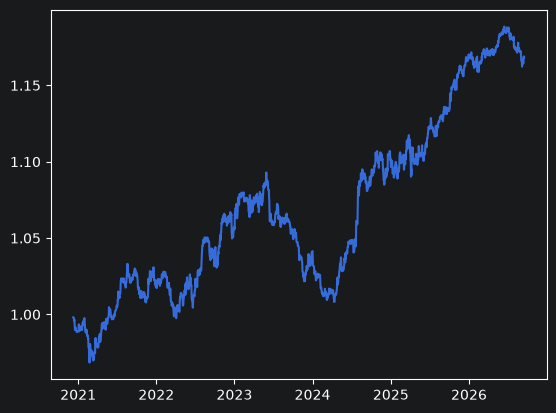

In [16]:
plt.plot(walk_forward_returns['timestamp'],walk_forward_returns['portfolio_equity'])

In [17]:
# Reload the latest saved artifacts for inference in a fresh kernel.
saved_weights = pl.read_parquet(WEIGHTS_ARTIFACT_PATH)
saved_model_bundle = joblib.load(MODEL_ARTIFACT_PATH)

if saved_model_bundle.get("artifact_version") != 1:
    raise ValueError("Unsupported multi-asset model artifact version")
if saved_model_bundle.get("ccys") != CCYS:
    raise ValueError("Saved model currency universe does not match CCYS")

saved_models = saved_model_bundle["models"]
saved_feature_columns = saved_model_bundle["feature_columns"]
missing_features = set(saved_feature_columns) - set(all.columns)
if missing_features:
    raise ValueError(f"Current features are missing saved model columns: {sorted(missing_features)}")

# Example: regenerated_weights = generate_weights(saved_models, all.tail(1), saved_feature_columns)
print(f"Loaded {saved_weights.height} saved weight rows and {len(saved_models)} currency models.")

Loaded 2100 saved weight rows and 7 currency models.


In [18]:
WEIGHTS_ARTIFACT_PATH

WindowsPath('C:/Code/Trading/2026/ml/src/notebooks/src/notebooks/multi_asset_weights_non_majors_oanda_2016_jan_fourth.parquet')

In [22]:
vol_returns, vol_metrics = calculate_strategy_returns_vol_targetting(saved_weights, all, target_volatility=0.2)

In [23]:
vol_metrics

rows,target_volatility,volatility_window,total_return,annualised_return,annualised_volatility,sharpe,max_drawdown
i64,f64,i64,f64,f64,f64,f64,f64
2100,0.2,20,0.986658,0.085862,0.229448,0.473915,-0.453927


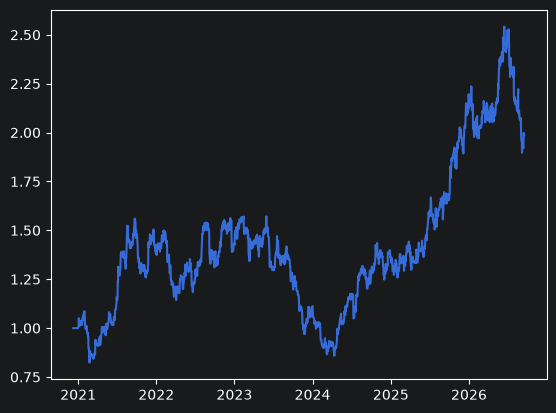

In [24]:
plt.plot(vol_returns['timestamp'],vol_returns['portfolio_equity'])

In [69]:
walk_forward_returns, walk_forward_metrics = calculate_strategy_returns(saved_weights, all)

In [70]:
walk_forward_returns

timestamp,jpy_prediction,chf_prediction,cad_prediction,aud_prediction,nzd_prediction,eur_prediction,gbp_prediction,jpy_weight,chf_weight,cad_weight,aud_weight,nzd_weight,eur_weight,gbp_weight,jpy_target,chf_target,cad_target,aud_target,nzd_target,eur_target,gbp_target,portfolio_return,portfolio_equity,portfolio_drawdown
"datetime[ns, UTC]",f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2020-12-06 00:00:00 UTC,0.000143,-0.00011,0.000003,0.000277,0.000297,0.00012,-0.000114,0.057075,-0.204172,-0.087889,0.194714,0.214939,0.033272,-0.20794,0.00328,0.002385,-0.00095,-0.001303,0.000738,-0.000003,-0.004147,0.000551,1.000551,0.0
2020-12-07 00:00:00 UTC,0.000132,0.000144,0.000132,0.000045,-0.000208,0.00006,0.000223,0.085579,0.104051,0.086302,-0.045804,-0.431259,-0.022936,0.224067,-0.001537,0.002748,-0.001191,-0.000995,0.000197,-0.000016,0.000795,0.000191,1.000742,0.0
2020-12-08 00:00:00 UTC,0.000132,-0.000041,0.000003,-0.000195,0.000451,0.000206,-0.000065,0.053349,-0.095684,-0.058141,-0.22954,0.329301,0.11735,-0.116635,-0.000654,-0.000029,-0.000078,0.00481,-0.003059,-0.002019,0.001029,-0.002496,0.998244,-0.002496
2020-12-09 00:00:00 UTC,0.000163,0.000111,0.00007,-0.000607,-0.000192,0.000147,0.000239,0.11105,0.077478,0.051286,-0.382947,-0.117053,0.100642,0.159544,-0.004712,-0.00125,0.001994,0.008164,0.006874,0.00037,-0.011442,-0.006237,0.992017,-0.008718
2020-12-10 00:00:00 UTC,0.000163,0.000187,0.000048,-0.000502,-0.000224,-0.000254,0.00005,0.159115,0.17467,0.082497,-0.283175,-0.098503,-0.118322,0.083718,0.004271,-0.002425,0.000025,0.003412,0.000737,-0.001116,-0.004904,-0.001059,0.990966,-0.009768
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-08-09 00:00:00 UTC,-0.000306,-0.00004,-0.000052,-0.000009,-0.000043,0.000031,0.000185,-0.44274,-0.011025,-0.030235,0.039634,-0.016001,0.105478,0.354887,-0.007766,-0.000807,0.002955,0.000307,0.001536,0.000458,0.003317,0.004571,1.411672,0.0
2026-08-10 00:00:00 UTC,-0.000251,0.00004,-0.000011,-0.000025,-0.000093,0.000094,0.000121,-0.369552,0.092167,0.010355,-0.012046,-0.118402,0.177322,0.220156,-0.000549,-0.001425,0.001415,0.00169,-0.001304,0.000028,0.000145,0.000257,1.412035,0.0
2026-08-11 00:00:00 UTC,-0.000296,0.000067,-0.000011,-0.000009,-0.000148,0.000062,0.000116,-0.346923,0.129598,0.026449,0.029287,-0.153077,0.121984,0.192683,0.001221,-0.001446,-0.00004,0.001651,-0.002103,0.00007,0.000648,-0.000108,1.411883,-0.000108


In [75]:
all[['timestamp','aud_return_1']]


timestamp,aud_return_1
"datetime[ns, UTC]",f64
2016-01-01 00:00:00 UTC,null
2016-01-02 00:00:00 UTC,0.0
2016-01-03 00:00:00 UTC,0.0
2016-01-04 00:00:00 UTC,-0.013839
2016-01-05 00:00:00 UTC,-0.003299
…,…
2026-08-27 00:00:00 UTC,0.001977
2026-08-28 00:00:00 UTC,-0.004753
2026-08-29 00:00:00 UTC,0.0


In [71]:
walk_forward_metrics

rows,total_return,annualised_return,annualised_volatility,sharpe,max_drawdown
i64,f64,f64,f64,f64,f64
2074,0.412637,0.042868,0.032578,1.304819,-0.037218


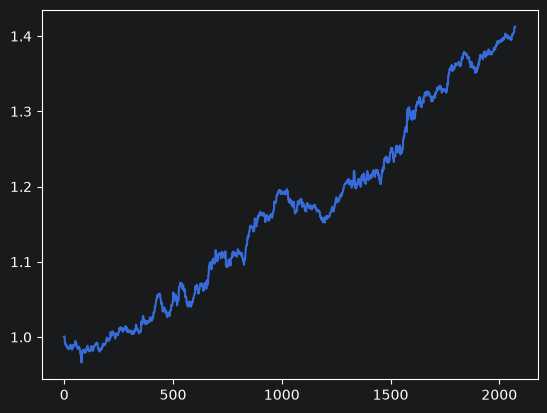

In [72]:
plt.plot(walk_forward_returns['portfolio_equity'])

In [21]:
# Pseudo-realistic trading simulation inputs (USD account).
SIMULATION_STARTING_BALANCE = 10_000.0
SIMULATION_MINIMUM_TRADE_SIZE = 1.0  # Currency units; positions are truncated toward zero to this lot size.
SIMULATION_TRADING_COST_RATE = 0.0000 # 1 basis point of USD turnover.
SIMULATION_TARGET_LEVERAGE = 1.0
simulation_config = TradingSimulationConfig(
    starting_balance=SIMULATION_STARTING_BALANCE,
    minimum_trade_size=SIMULATION_MINIMUM_TRADE_SIZE,
    trading_cost_rate=SIMULATION_TRADING_COST_RATE,
    target_leverage=SIMULATION_TARGET_LEVERAGE,
)
simulation_ledger, simulation_summary = simulate_weight_trading(
    saved_weights, all_raw, simulation_config
)
simulation_summary

rows,starting_balance_usd,ending_equity_usd,total_pnl_usd,total_trading_cost_usd,total_turnover_usd,total_return,annualised_return,annualised_volatility,sharpe,max_drawdown
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2074,10000.0,13408.424329,3408.424329,0.0,2.2373e7,0.340842,0.03628,0.027772,1.297154,-0.031811


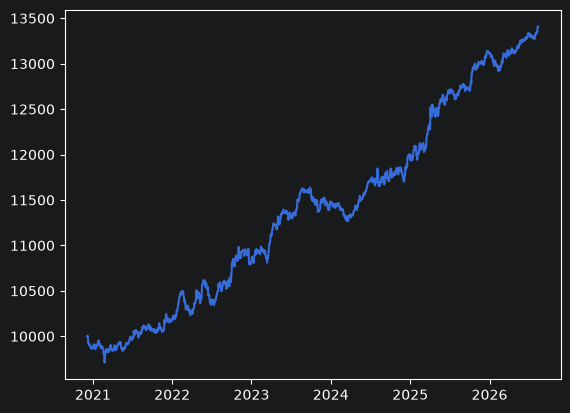

In [22]:
plt.plot(simulation_ledger['timestamp'], simulation_ledger['starting_equity_usd'])

In [34]:
simulation_ledger.columns

['timestamp',
 'starting_equity_usd',
 'turnover_usd',
 'trading_cost_usd',
 'pnl_usd',
 'gross_exposure_usd',
 'ending_equity_usd',
 'is_final_liquidation',
 'jpy_target_units',
 'jpy_position_units',
 'jpy_trade_units',
 'chf_target_units',
 'chf_position_units',
 'chf_trade_units',
 'cad_target_units',
 'cad_position_units',
 'cad_trade_units',
 'aud_target_units',
 'aud_position_units',
 'aud_trade_units',
 'nzd_target_units',
 'nzd_position_units',
 'nzd_trade_units',
 'eur_target_units',
 'eur_position_units',
 'eur_trade_units',
 'gbp_target_units',
 'gbp_position_units',
 'gbp_trade_units',
 'simulation_return',
 'equity_drawdown']